# Notebook 07 — GNNExplainer Attribution for SMILESGNN

This notebook demonstrates how to use **GNNExplainer** (Ying et al., 2019) to
generate atom- and bond-level importance scores for the trained SMILESGNN model.

## What it does

GNNExplainer optimises binary masks over node features and edges to find the
minimal subgraph that is sufficient to reproduce the model's prediction.  
Because SMILESGNN fuses a Transformer SMILES encoder with a GATv2 graph encoder,
we **freeze the SMILES embedding per molecule** and only allow GNNExplainer to
perturb the graph pathway.  This gives explanations that are faithful to the
structural (atom/bond) information the model uses.

## Sections

1. Setup
2. Load trained model
3. Explain a single molecule
4. Batch explain — all toxic molecules in the test set
5. Aggregate element-level importance
6. Limitations and next steps

---
> **Prerequisite**: run `python scripts/train_hybrid.py` first so that
> `models/smilesgnn_model/best_model.pt` and `tokenizer.pkl` exist.

## 1. Setup

In [1]:
import sys
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Project root (one level above notebooks/)
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import torch
import matplotlib.pyplot as plt

from src.data import load_clintox
from src.graph_data import smiles_list_to_pyg_dataset, smiles_to_pyg_data, get_feature_dims
from src.graph_models_hybrid import create_hybrid_model
from src.gnn_explainer import (
    explain_molecule,
    visualize_explanation,
    batch_explain,
    aggregate_atom_importance,
    plot_element_importance,
)

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_DIR   = PROJECT_ROOT / 'models' / 'smilesgnn_model'
CONFIG_PATH = PROJECT_ROOT / 'config' / 'smilesgnn_config.yaml'

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_DIR}')

Device : cuda
Model  : C:\Users\LENOVO\Documents\PYTHON\BRT\XSMILES\models\smilesgnn_model


## 2. Load the trained model

In [2]:
# --- Load config ----------------------------------------------------------- #
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)
mc = config['model']

# --- Load tokenizer FIRST -------------------------------------------------- #
# The config sets smiles_vocab_size=100 as an upper bound, but the tokenizer
# is built from actual training SMILES and typically contains fewer tokens.
# The saved checkpoint uses the real vocab size, so we must match it here.
with open(MODEL_DIR / 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

actual_vocab_size = len(tokenizer.token_to_id)
print(f'Actual vocabulary size: {actual_vocab_size}')

# --- Rebuild model with the real vocab size -------------------------------- #
num_node_features, num_edge_features = get_feature_dims()

model = create_hybrid_model(
    num_node_features = num_node_features,
    num_edge_features = num_edge_features,
    hidden_dim        = int(mc['hidden_dim']),
    num_graph_layers  = int(mc['num_graph_layers']),
    graph_model       = mc['graph_model'],
    num_heads         = int(mc['num_heads']),
    dropout           = float(mc['dropout']),
    use_residual      = bool(mc.get('use_residual', True)),
    use_jk            = bool(mc.get('use_jk', True)),
    jk_mode           = mc.get('jk_mode', 'cat'),
    graph_pooling     = mc.get('graph_pooling', 'meanmax'),
    smiles_vocab_size = actual_vocab_size,   # <-- real vocab, not config default
    smiles_d_model    = int(mc['smiles_d_model']),
    smiles_num_layers = int(mc['smiles_num_layers']),
    fusion_method     = mc.get('fusion_method', 'attention'),
)

# --- Load checkpoint ------------------------------------------------------- #
state = torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

num_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded  — {num_params:,} parameters')

Actual vocabulary size: 68
Model loaded  — 411,265 parameters


## 3. Explain a single molecule

We start with **Thalidomide** (`O=C1CCC(=O)N1c1ccc2c(c1)C(=O)N(C2=O)`).
Thalidomide is a well-known clinical teratogen; SMILESGNN correctly predicts it as **toxic**.

> Change `SMILES` below to any molecule of interest.

In [3]:
# Thalidomide — a known teratogen
SMILES = 'O=C1CCC(=O)N1c1ccc2c(c1)C(=O)N(C2=O)'

# Convert SMILES → PyG Data object
pyg_data = smiles_to_pyg_data(SMILES, label=1)   # label=1 (toxic)

print(f'Atoms  : {pyg_data.num_nodes}')
print(f'Bonds  : {pyg_data.num_edges // 2}')

Atoms  : 18
Bonds  : 20


In [4]:
# Run GNNExplainer
# epochs=200 is a good default; increase to 500 for higher-quality masks
result = explain_molecule(
    smiles       = SMILES,
    model        = model,
    tokenizer    = tokenizer,
    pyg_data     = pyg_data,
    device       = DEVICE,
    epochs       = 200,
    target_class = 1,      # explain the 'toxic' prediction
)

print(f"Prediction : {'Toxic' if result['predicted_class'] == 1 else 'Non-toxic'}")
print(f"P(toxic)   : {result['prediction_prob']:.4f}")
print(f"True label : {result['true_label']}")

Prediction : Non-toxic
P(toxic)   : 0.0559
True label : 1


In [5]:
# Print top atoms by importance
from rdkit import Chem
mol = Chem.MolFromSmiles(SMILES)
atom_imp = result['atom_importance']

print('Top-10 atoms by GNNExplainer importance:')
print(f'  {"Rank":<5} {"Atom idx":<10} {"Symbol":<8} {"Importance"}')
print('  ' + '-' * 40)
ranked = sorted(enumerate(atom_imp), key=lambda x: x[1], reverse=True)[:10]
for rank, (idx, imp) in enumerate(ranked, 1):
    sym = mol.GetAtomWithIdx(idx).GetSymbol()
    print(f'  {rank:<5} {idx:<10} {sym:<8} {imp:.4f}')

Top-10 atoms by GNNExplainer importance:
  Rank  Atom idx   Symbol   Importance
  ----------------------------------------
  1     17         O        1.0000
  2     12         C        0.9450
  3     5          O        0.9331
  4     14         O        0.9258
  5     3          C        0.9092
  6     9          C        0.8960
  7     13         C        0.8946
  8     11         C        0.8760
  9     2          C        0.8740
  10    7          C        0.8626


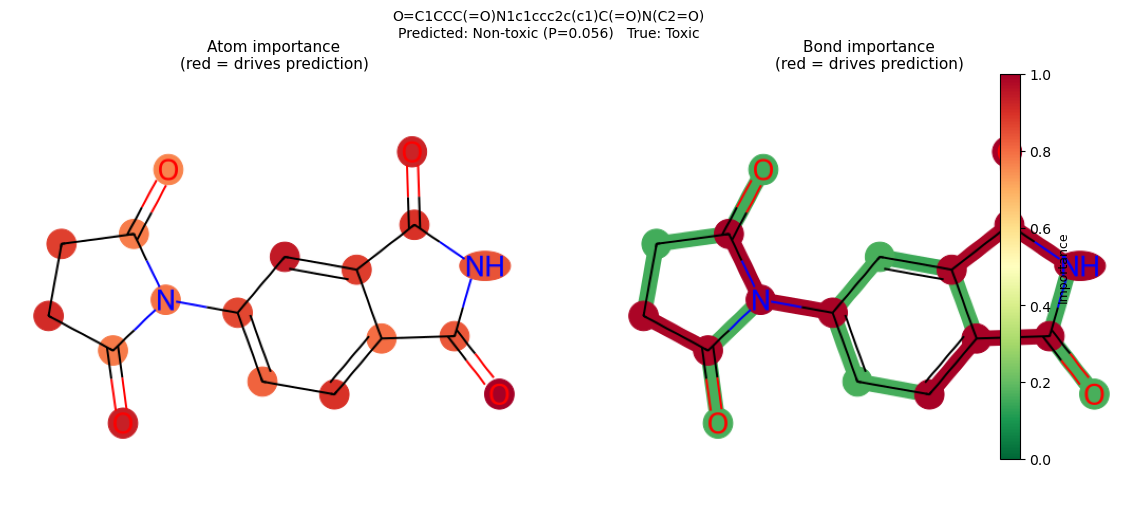

In [6]:
# Visualise — atom heatmap (left) and bond heatmap (right)
# Red = high importance (drives toxic prediction)
# Green = low importance
visualize_explanation(
    result,
    figsize        = (12, 5),
    atom_threshold = 0.4,
    bond_threshold = 0.4,
    # save_path = 'explanation_thalidomide.png'  # uncomment to save
)

### 3b. Quick scan: model predictions on a few known compounds

In [7]:
known_compounds = [
    # (name,                      SMILES,                                    expected_label)
    ('Thalidomide (toxic)',        'O=C1CCC(=O)N1c1ccc2c(c1)C(=O)N(C2=O)', 1),
    ('Aspirin (non-toxic)',        'CC(=O)Oc1ccccc1C(=O)O',                  0),
    ('Cisplatin (toxic)',          '[NH3][Pt](Cl)(Cl)[NH3]',                  1),
    ('Caffeine (non-toxic)',       'Cn1cnc2c1c(=O)n(C)c(=O)n2C',            0),
]

print(f'{"Compound":<30} {"P(toxic)":>10}  {"Predicted":>12}  {"Expected":>10}')
print('-' * 70)
for name, smi, expected in known_compounds:
    pyg = smiles_to_pyg_data(smi, label=expected)
    if pyg is None:
        print(f'{name:<30}  [parse error]')
        continue
    res = explain_molecule(smi, model, tokenizer, pyg, device=DEVICE, epochs=100)
    pred  = 'Toxic' if res['predicted_class'] == 1 else 'Non-toxic'
    exp   = 'Toxic' if expected == 1 else 'Non-toxic'
    match = '✓' if res['predicted_class'] == expected else '✗'
    print(f'{name:<30} {res["prediction_prob"]:>10.4f}  {pred:>12}  {exp:>10}  {match}')

Compound                         P(toxic)     Predicted    Expected
----------------------------------------------------------------------
Thalidomide (toxic)                0.0559     Non-toxic       Toxic  ✗
Aspirin (non-toxic)                0.0377     Non-toxic   Non-toxic  ✓


[15:58:26] Explicit valence for atom # 0 N, 4, is greater than permitted
[15:58:26] 

****
Pre-condition Violation
getExplicitValence() called without call to calcExplicitValence()
Violation occurred on line 308 in file C:\rdkit\build\temp.win-amd64-cpython-311\Release\rdkit\Code\GraphMol\Atom.cpp
Failed Expression: d_explicitValence > -1
****



RuntimeError: Pre-condition Violation
	getExplicitValence() called without call to calcExplicitValence()
	Violation occurred on line 308 in file Code\GraphMol\Atom.cpp
	Failed Expression: d_explicitValence > -1
	RDKIT: 2022.09.5
	BOOST: 1_78


## 4. Batch explain — all toxic molecules in the test set

The test set contains 10 toxic molecules. We explain all of them to identify
which structural features are consistently important across true positives.

In [8]:
# Load ClinTox test split
dc = config['data']
_, _, test_df = load_clintox(
    cache_dir  = str(PROJECT_ROOT / dc['cache_dir']),
    split_type = dc['split_type'],
    seed       = dc['seed'],
)

print(f'Test set: {len(test_df)} molecules')
print(f'  Toxic    : {test_df["CT_TOX"].sum()}')
print(f'  Non-toxic: {(test_df["CT_TOX"] == 0).sum()}')

Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (c:\Users\LENOVO\anaconda3\envs\drug-tox-env\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Test set: 148 molecules
  Toxic    : 10.0
  Non-toxic: 138


In [9]:
# Keep only toxic test molecules
toxic_df     = test_df[test_df['CT_TOX'] == 1].reset_index(drop=True)
toxic_smiles = toxic_df['smiles'].tolist()
toxic_labels = toxic_df['CT_TOX'].tolist()

print(f'Explaining {len(toxic_smiles)} toxic test molecules …')

toxic_pyg = smiles_list_to_pyg_dataset(toxic_smiles, labels=toxic_labels)

toxic_results = batch_explain(
    smiles_list = toxic_smiles,
    labels      = toxic_labels,
    model       = model,
    tokenizer   = tokenizer,
    pyg_dataset = toxic_pyg,
    device      = DEVICE,
    epochs      = 200,
)

Explaining 10 toxic test molecules …
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C…



--- Molecule 1/10: C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl ---


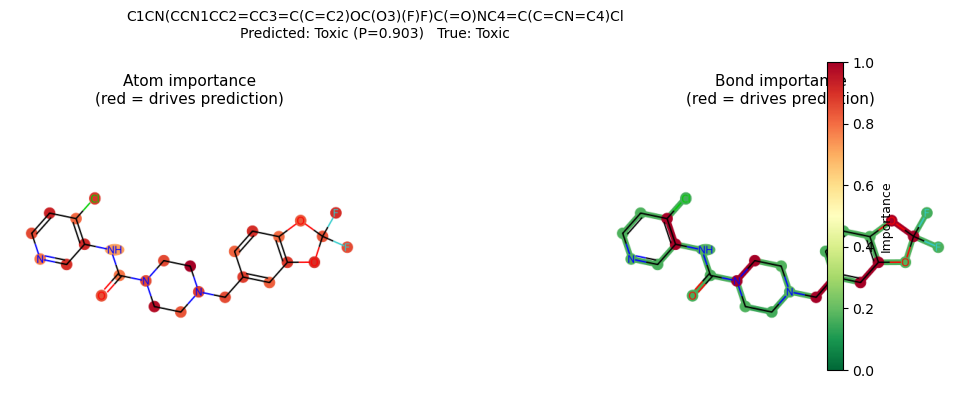


--- Molecule 2/10: C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)F)NC4=C(C=C(C= ---


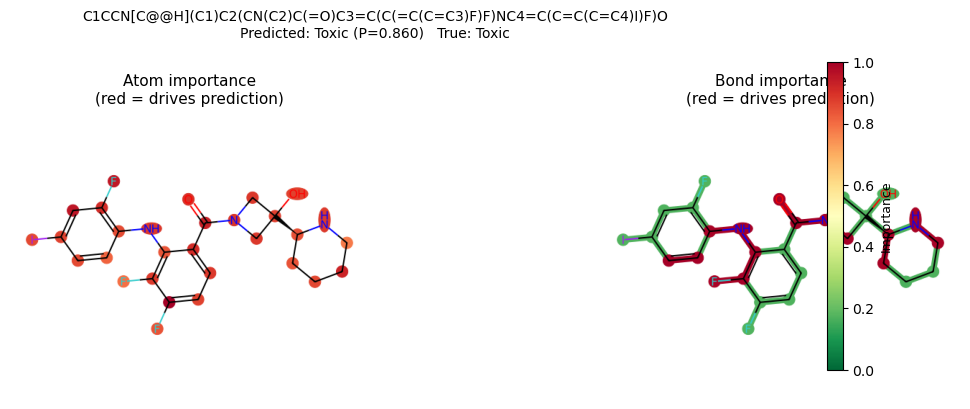


--- Molecule 3/10: C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2 ---


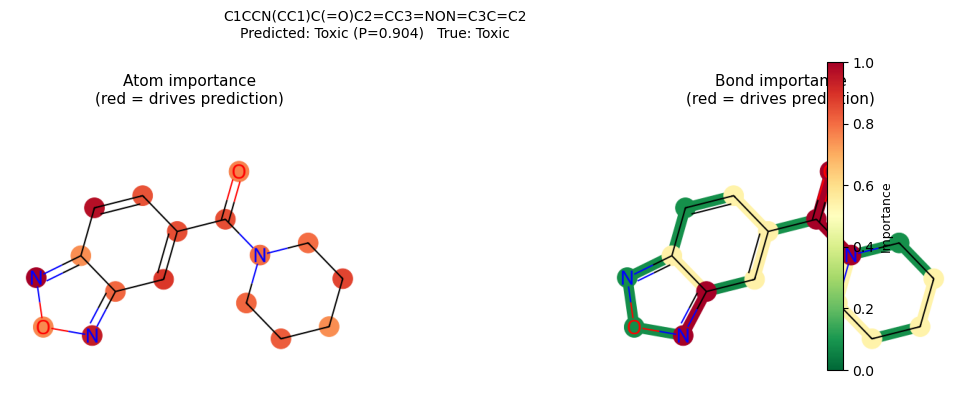


--- Molecule 4/10: C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=NC=C4 ---


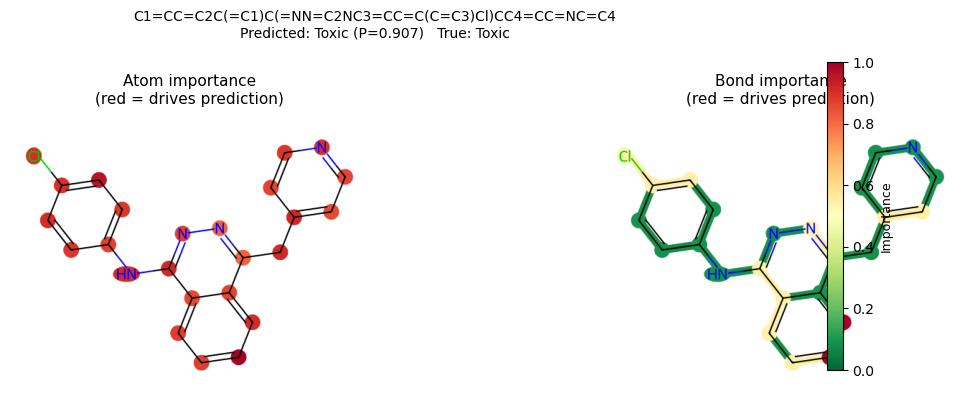


--- Molecule 5/10: C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C/C(=O)NO ---


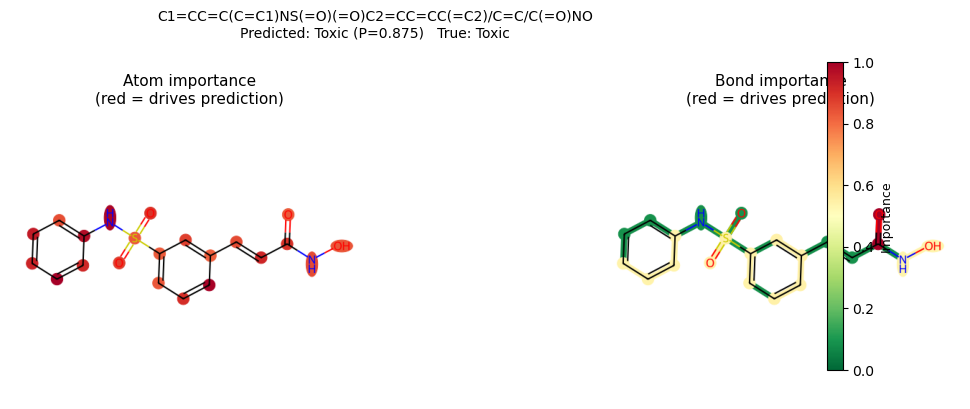


--- Molecule 6/10: C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(=O)C2=CC=C(C=C2)NCC3 ---


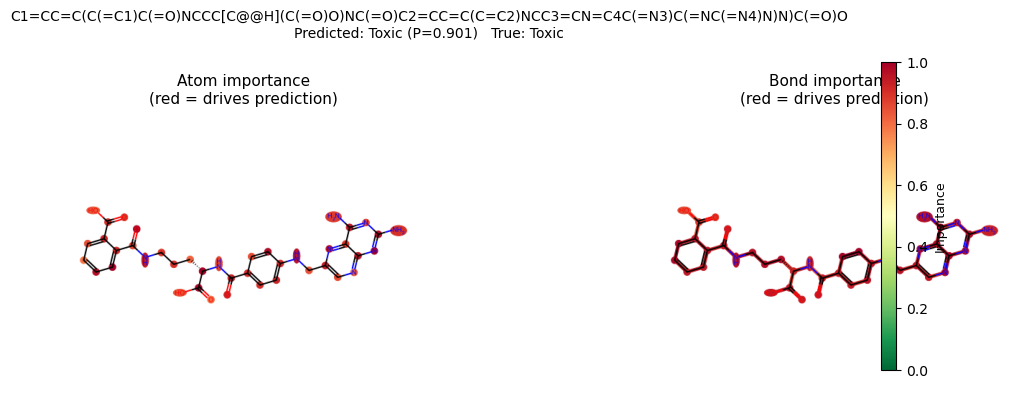


--- Molecule 7/10: C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4=C(C(=CC=C4)Cl)Cl ---


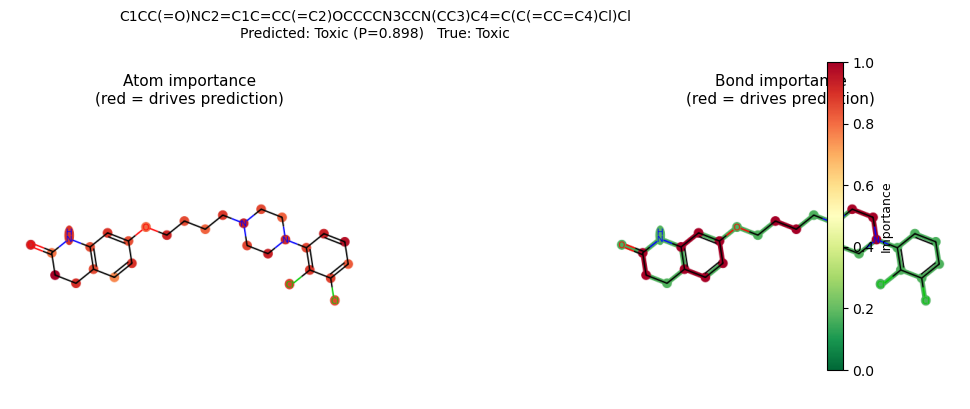


--- Molecule 8/10: C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3 ---


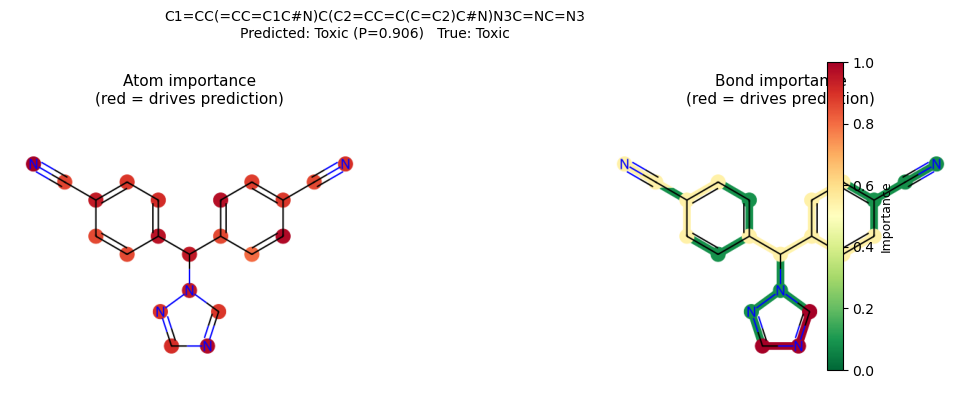


--- Molecule 9/10: C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt] ---


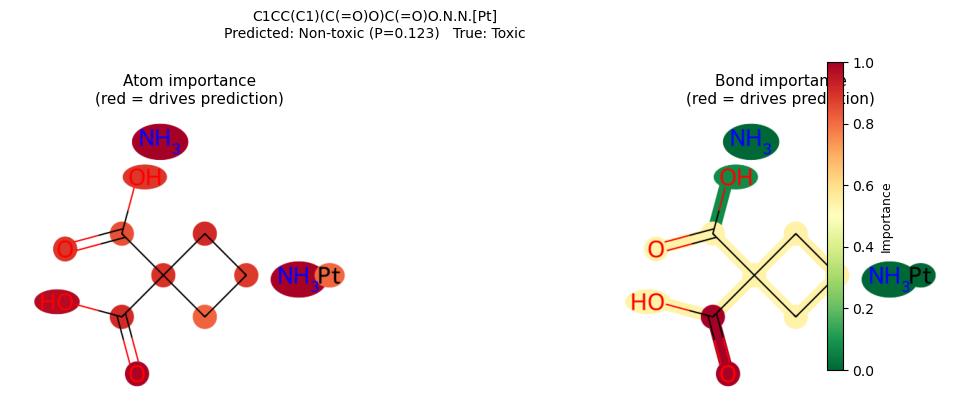


--- Molecule 10/10: C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br ---


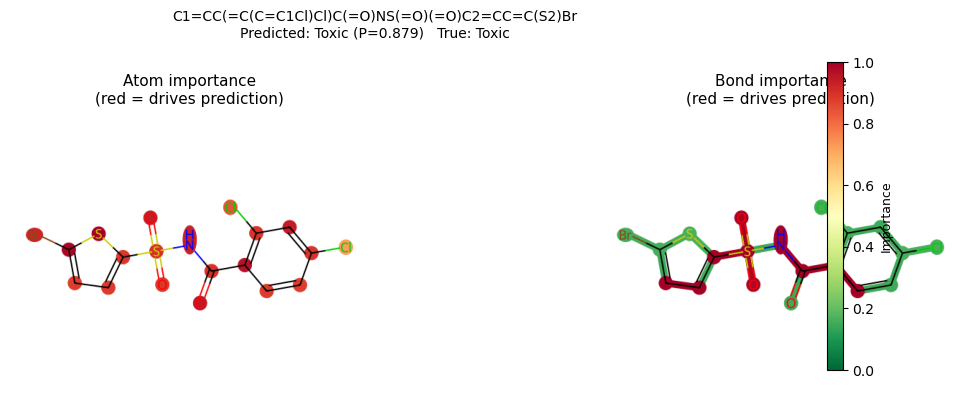

In [10]:
# Display all toxic molecule explanations
for i, res in enumerate(toxic_results):
    print(f'\n--- Molecule {i+1}/{len(toxic_results)}: {res["smiles"][:60]} ---')
    visualize_explanation(
        res,
        figsize        = (12, 4),
        atom_threshold = 0.4,
        bond_threshold = 0.4,
        # save_path = f'explanation_toxic_{i:02d}.png'  # uncomment to save
    )

## 5. Aggregate element-level importance

We aggregate the per-atom importance scores across all toxic molecules and
compute the mean importance for each chemical element.

> **Note**: GNNExplainer importance reflects the graph pathway only. Use these
> results as hypotheses to test against domain knowledge.

In [11]:
# Aggregate over toxic molecules
element_scores = aggregate_atom_importance(toxic_results, label_filter=1)

print('Mean GNNExplainer importance by element (toxic test set):')
print(f'  {"Element":<10} {"Mean importance"}')
print('  ' + '-' * 28)
for elem, score in sorted(element_scores.items(), key=lambda x: x[1], reverse=True):
    print(f'  {elem:<10} {score:.4f}')

Mean GNNExplainer importance by element (toxic test set):
  Element    Mean importance
  ----------------------------
  Br         0.9187
  S          0.9108
  N          0.9052
  C          0.8863
  O          0.8780
  F          0.8680
  I          0.8590
  Cl         0.8484
  Pt         0.8090


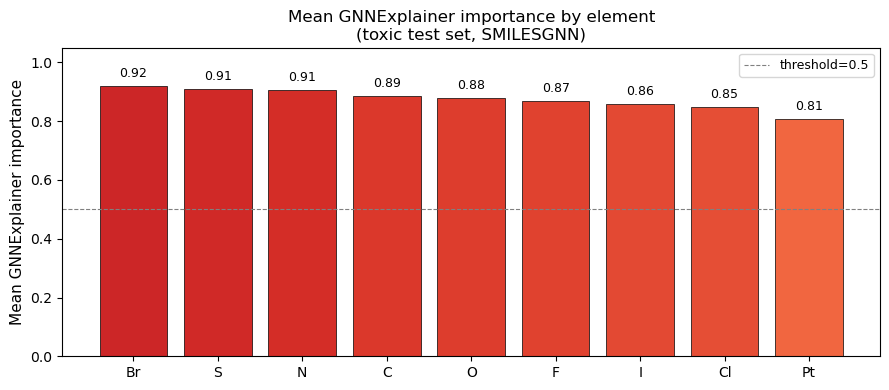

In [12]:
plot_element_importance(
    element_scores,
    title = 'Mean GNNExplainer importance by element\n(toxic test set, SMILESGNN)',
    # save_path = 'element_importance_toxic.png'  # uncomment to save
)

In [13]:
# Compare: element importance in non-toxic test molecules
nontoxic_df     = test_df[test_df['CT_TOX'] == 0].reset_index(drop=True)
nontoxic_smiles = nontoxic_df['smiles'].tolist()
nontoxic_labels = nontoxic_df['CT_TOX'].tolist()
nontoxic_pyg    = smiles_list_to_pyg_dataset(nontoxic_smiles, labels=nontoxic_labels)

print(f'Explaining {len(nontoxic_smiles)} non-toxic test molecules …')

nontoxic_results = batch_explain(
    smiles_list = nontoxic_smiles,
    labels      = nontoxic_labels,
    model       = model,
    tokenizer   = tokenizer,
    pyg_dataset = nontoxic_pyg,
    device      = DEVICE,
    epochs      = 200,
)

nontoxic_scores = aggregate_atom_importance(nontoxic_results, label_filter=0)

Explaining 138 non-toxic test molecules …
[138/138] [H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])N)cc…


In [14]:
# Side-by-side comparison
import pandas as pd

all_elements = sorted(set(element_scores) | set(nontoxic_scores))
compare = pd.DataFrame({
    'Element'  : all_elements,
    'Toxic'    : [element_scores.get(e, 0.0) for e in all_elements],
    'Non-toxic': [nontoxic_scores.get(e, 0.0) for e in all_elements],
})
compare['Difference'] = compare['Toxic'] - compare['Non-toxic']
compare = compare.sort_values('Difference', ascending=False)
print(compare.to_string(index=False, float_format='{:.4f}'.format))

Element  Toxic  Non-toxic  Difference
     Br 0.9187     0.8139      0.1047
      N 0.9052     0.8827      0.0225
      C 0.8863     0.8870     -0.0007
      S 0.9108     0.9120     -0.0012
      O 0.8780     0.8876     -0.0096
      F 0.8680     0.8790     -0.0110
      I 0.8590     0.8901     -0.0311
     Cl 0.8484     0.8942     -0.0458
     Pt 0.8090     0.8880     -0.0790
      H 0.0000     0.8627     -0.8627
      P 0.0000     0.9090     -0.9090
     Bi 0.0000     0.9150     -0.9150


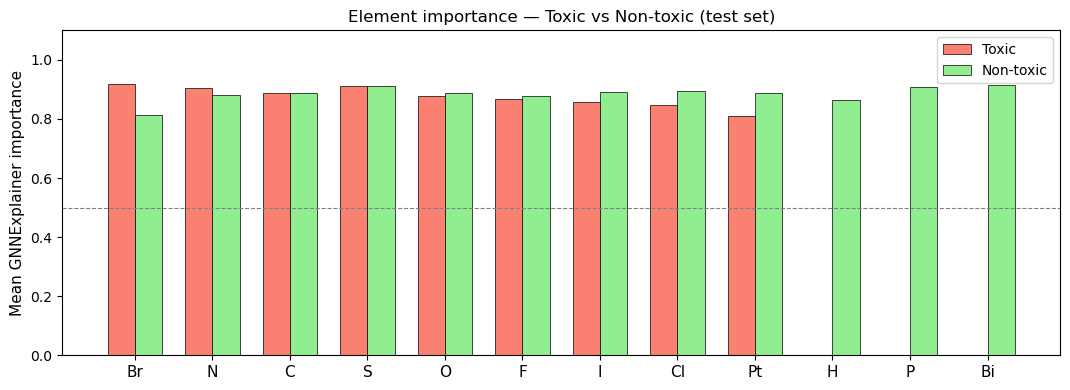

In [15]:
# Grouped bar chart: toxic vs non-toxic element importance
import numpy as np

elems = compare['Element'].tolist()
x     = np.arange(len(elems))
width = 0.35

fig, ax = plt.subplots(figsize=(max(8, len(elems) * 0.9), 4))
ax.bar(x - width/2, compare['Toxic'].tolist(),     width, label='Toxic',     color='salmon',     edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, compare['Non-toxic'].tolist(), width, label='Non-toxic', color='lightgreen', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(elems, fontsize=11)
ax.set_ylabel('Mean GNNExplainer importance', fontsize=11)
ax.set_title('Element importance — Toxic vs Non-toxic (test set)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Limitations and next steps

### What GNNExplainer does well here
- Produces atom- and bond-level importance scores without retraining.
- Faithful to the **graph pathway**: masks are optimised against the exact model prediction.
- Faster than retraining an intrinsically interpretable model.

### Known limitations

| Limitation | Detail |
|---|---|
| Frozen SMILES embedding | Explanations reflect the graph pathway only. If the Transformer SMILES encoder drives the prediction, atom/bond scores may be misleading. |
| Attention ≠ attribution | GATv2 attention weights are **not** the same as GNNExplainer masks. |
| No chemical constraint | Masks can highlight chemically implausible subgraphs. |
| Optimisation noise | Results vary slightly across runs. Increase `epochs` for more stable masks. |

### Next steps
- **Subgraph faithfulness test**: compare model output with only the top-k atoms retained vs. removed.
- **SHAP for the SMILES pathway**: run `shap.DeepExplainer` on the Transformer encoder to get token-level importance.
- **Cross-validate against toxicophore databases**: check whether high-importance atoms overlap with known PAINS / Brenk structural alerts.